# Project 1 - Graph Search

refer to the project write up [here](https://rutgers.app.box.com/s/nmmj14j4g70nbltswcq8ooeqde3okp5x)

### The Ship

 - This is represented with an nxn grid of closed cells
 - Choose a random interior square to 'open'
 - neighbors of a cell are 1 unit away in cardinal directions
 - Iteratively: open up the ship, following protocol described in writeup
 - Identify dead ends -> for half of them pick a closed neighbor and open it

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [45]:
matr = np.random.randn(3,3)

for ind, cell in np.ndenumerate(matr):
    print(f'Index: {ind}, cell: {cell}')

Index: (0, 0), cell: -0.6838577703541406
Index: (0, 1), cell: -0.17362768226016126
Index: (0, 2), cell: -1.1180393149895753
Index: (1, 0), cell: -0.3462853780596995
Index: (1, 1), cell: 1.8179820808123786
Index: (1, 2), cell: 0.08988034575422195
Index: (2, 0), cell: -1.2018532063613974
Index: (2, 1), cell: -1.069854140161988
Index: (2, 2), cell: 0.9061333634616066


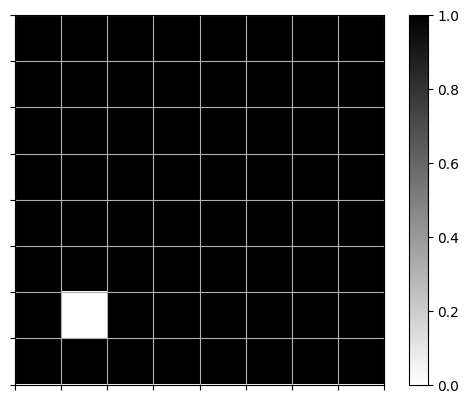

In [43]:
#Make nxn grid using numpy matrix. 1 -> closed, 0 -> open
def CreateShip(n):
    ship = np.ones((n,n), dtype = float)

    #Pick random cell to open
    x_rand, y_rand = random.randint(0, ship.shape[0]-1) , random.randint(0, ship.shape[1]-1)
    ship[x_rand][y_rand] = 0

    return ship


def checkNeighbors(ship, currInd): #We call this on a closed cell to see if it has exactly 1 open neighbor, returns a boolean
    up = (currInd[0]-1, currInd[1])
    down = (currInd[0]+1, currInd[1])
    left = (currInd[0], currInd[1]-1)
    right = (currInd[0], currInd[1]+1)

    dir = [up, down, left, right]
    while k in range(len(dir)):
        i,j = dir[k] #unpack coordinate tuple
        if i < 0 or i > ship.shape[0]-1 or j < 0 or j > ship.shape[0]-1:
            del dir[k] #delete a direction if its out of bounds
    numOpen = 0
    for direction in dir:
        if ship[direction[0]][direction[1]] == 0:
            numOpen+=1
    if numOpen == 1:
        return True
    return False

def getBlocked(ship): #Helper method that returns a list of closed cells with exactly one neighbor
    blocked = [] #Will hold tuples of indices of blocked cells with exactly 1 open neighbor
    for index, cell in np.ndenumerate(ship):
        if cell == 1:
            if checkNeigbors(ship, index): blocked.append(index) #add to blocked if checkNeighbors is true
    return blocked
        


def ShowShip(ship):
    plt.imshow(ship, cmap = 'binary', interpolation = None)

    #Ensure shows plot with increments of 1
    plt.xticks(np.arange(-0.5, ship.shape[1], 1), labels=[])
    plt.yticks(np.arange(-0.5, ship.shape[0], 1), labels=[])

    #Show gridlines
    plt.grid(True)

    #Show colorbar
    plt.colorbar()
    plt.show()

ship = CreateShip(8)
ShowShip(ship)

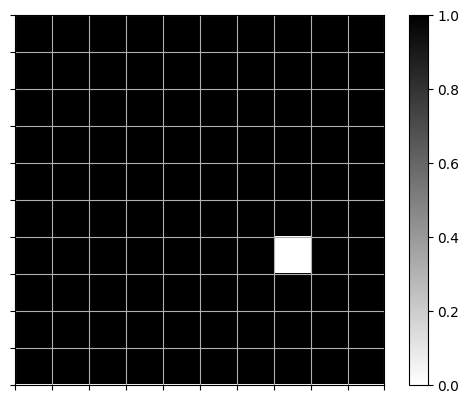

[(6, 7)]

In [16]:
class ship:
    def __init__(self,data, open = None, fire = None, button = None, bot = None):
        self.data = data # this should be numpy matrix
        self.open = open # list of tuples, each tuple has indices of open cell
        self.fire = fire # list of tuples, each tuple has indices of fire cell
        self.button = button #tuple
        self.bot = bot #tuple

    @classmethod
    def CreateShip(cls,n):
        ship = cls(np.ones((n,n), dtype = float))
    
        #Pick random cell to open
        x_rand, y_rand = random.randint(1, ship.data.shape[0]-2) , random.randint(1, ship.data.shape[1]-2)
        ship.data[x_rand][y_rand] = 0
        ship.open = [(x_rand, y_rand)]
        return ship

    def ShowShip(self):
        plt.imshow(self.data, cmap = 'binary', interpolation = None)

        #Ensure shows plot with increments of 1
        plt.xticks(np.arange(-0.5, self.data.shape[1], 1), labels=[])
        plt.yticks(np.arange(-0.5, self.data.shape[0], 1), labels=[])

        #Show gridlines
        plt.grid(True)

        #Show colorbar
        plt.colorbar()
        plt.show()

    # Helper method, takes in an open cell, checks its neighbors and returns list of tuples that can be opened
    def checkNeighborsOpen(self, openInd):
        up = (openInd[0]-1, openInd[1])
        down = (openInd[0]+1, openInd[1])
        left = (openInd[0], openInd[1]-1)
        right = (openInd[0], openInd[1]+1)

        dir = [up, down, left, right]
        while k in range(len(dir)):
            i,j = dir[k] #unpack coordinate tuple
            if i < 0 or i > self.data.shape[0]-1 or j < 0 or j > self.data.shape[0]-1:
                del dir[k] #delete a direction if its out of bounds
            if self.data[i][j] == 0:
                del dir[k]
        return dir
        
    #Takes in single tuple which is closed index. Checks to see if it has exactly one open neighbor
    def checkNeighborsClosed(self, closedInd):
        up = (closedInd[0]-1, closedInd[1])
        down = (closedInd[0]+1, closedInd[1])
        left = (closedInd[0], closedInd[1]-1)
        right = (closedInd[0], closedInd[1]+1)

        dir = [up, down, left, right]
        while k in range(len(dir)):
            i,j = dir[k] #unpack coordinate tuple
            if i < 0 or i > self.data.shape[0]-1 or j < 0 or j > self.data.shape[0]-1:
                del dir[k] #delete a direction if its out of bounds
        numOpen = 0
        for direction in dir:
            if self.data[direction[0]][direction[1]] == 0:
                numOpen+=1
        if numOpen == 1:return True
        return False
        
    def OpenShip(self):
        pass
    

space_ship = ship.CreateShip(10)
space_ship.ShowShip()
space_ship.open